# VERSION WITH PROBABILITY THRESHOLD 0.8

# ML Predictor Comparison: Baseline vs Probability Filter

This notebook compares the original predictor in `ML_predictor.py` with the probability-aware predictor in `ML_predictor_probability.py`.

Both strategies use the same data, walk-forward training window, feature grid, signal thresholds, backtester, and execution settings. The probability strategy uses `probability_threshold=0.80`, so it assigns a non-zero weight only when its most likely class has probability strictly above 80%.

The structure follows `test_PCA_scaler_comparison.ipynb`: parallel grid execution, saved case artifacts, performance leaderboards, matched-grid deltas, heatmaps, prediction agreement, diagnostics, and winner equity curves.

## 1. Setup

In [1]:
from pathlib import Path
import sys
import time
import json
import itertools
import warnings

from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

cwd = Path.cwd().resolve()
repo_root = cwd
while repo_root.name != "Bluegrey" and repo_root.parent != repo_root:
    repo_root = repo_root.parent

ml_dir = repo_root / "research" / "Mateo" / "ML_predictor"
src_dir = repo_root / "src"
for path in [repo_root, src_dir, ml_dir]:
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from ML_predictor import MLPredictorStrategy as BaselineStrategy
from ML_predictor_probability import MLPredictorStrategy as ProbabilityStrategy
from src.vector_backtester_Mateo import PortfolioVectorEngine

print(f"Repo root: {repo_root}")
print(f"ML directory: {ml_dir}")

Repo root: /Users/mateo/Bluegrey
ML directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 2. Grid Specification

The requested grid contains 72 runs: two strategies × nine `n_features` values × four `signal_threshold` values. `training_years` is fixed at 10.

In [2]:
SYMBOL = "ECH"
ASSET_CLASS = "STK"
INITIAL_CAPITAL = 1_000_000
EXECUTION_DELAY = 1

STRATEGIES = {
    "baseline": BaselineStrategy,
    "probability_80pct": ProbabilityStrategy,
}
TRAINING_YEARS = 10
N_FEATURES_GRID = list(range(3, 20, 2))
SIGNAL_THRESHOLD_GRID = [0.000, 0.001, 0.002, 0.003]
PROBABILITY_THRESHOLD = 0.80

COMMON_PARAMS = {
    "symbol": SYMBOL,
    "start_date": "2025-01-01",
    "end_date": "2026-01-01",
    "training_years": TRAINING_YEARS,
    "download_data": False,
    "position_size": 1.0,
    "max_iter": 5000,
    "verbose": False,
}

RUN_GRID = True
N_JOBS = 12
PARALLEL_VERBOSE = 10
SHOW_PROGRESS = False
SAVE_ARTIFACTS = True

OUTPUT_DIR = ml_dir / "test_probability_strategy_comparison_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

grid_cases = list(itertools.product(STRATEGIES, N_FEATURES_GRID, SIGNAL_THRESHOLD_GRID))
assert N_FEATURES_GRID == [3, 5, 7, 9, 11, 13, 15, 17, 19]
assert SIGNAL_THRESHOLD_GRID == [0.000, 0.001, 0.002, 0.003]
assert len(grid_cases) == 72

print(f"Grid cases: {len(grid_cases)} ({len(grid_cases) // len(STRATEGIES)} matched points per strategy)")
print(f"Output directory: {OUTPUT_DIR}")

Grid cases: 72 (36 matched points per strategy)
Output directory: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/test_probability_strategy_comparison_outputs


## 3. Helper Functions

These helpers follow the PCA comparison notebook's conventions for run IDs, performance statistics, artifact persistence, and self-contained single-case execution.

In [3]:
def safe_value(value):
    if isinstance(value, (float, np.floating)):
        value = float(value)
        if value.is_integer():
            return str(int(value))
        return f"{value:g}".replace(".", "p")
    return str(value)


def make_run_id(symbol: str, strategy_name: str, n_features: int, signal_threshold: float) -> str:
    return (
        f"{symbol}_strategy-{strategy_name}"
        f"_features-{n_features}"
        f"_sig-{safe_value(signal_threshold)}"
    )


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    volatility = returns.std()
    if volatility == 0 or np.isnan(volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / volatility


def annualized_sortino(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    downside_volatility = returns[returns < 0].std()
    if downside_volatility == 0 or np.isnan(downside_volatility):
        return np.nan
    return np.sqrt(periods_per_year) * returns.mean() / downside_volatility


def max_drawdown(equity: pd.Series) -> float:
    return (equity / equity.cummax() - 1.0).min()


def summarize_performance(
    run_id: str,
    strategy_name: str,
    params: dict,
    stats: pd.DataFrame,
    weights: pd.DataFrame,
    predictions: pd.DataFrame,
    elapsed_seconds: float,
) -> dict:
    gross_return_pct = (stats["gross_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    net_return_pct = (stats["net_equity"].iloc[-1] / INITIAL_CAPITAL - 1.0) * 100
    benchmark_return_pct = (stats["cum_benchmark"].iloc[-1] - 1.0) * 100
    gross_bar_returns = stats["gross_returns"].iloc[1:]
    exposure = weights.abs().sum(axis=1)
    turnover = weights.diff().abs().sum(axis=1).fillna(0)
    prediction_counts = predictions["prediction"].value_counts(normalize=True).sort_index() * 100
    max_probability = predictions.get("max_probability", pd.Series(np.nan, index=predictions.index))
    passed_filter = predictions.get("passes_probability_threshold", pd.Series(True, index=predictions.index))

    return {
        "run_id": run_id,
        "strategy": strategy_name,
        "symbol": params["symbol"],
        "n_features": params["n_features"],
        "signal_threshold": params["signal_threshold"],
        "training_years": params["training_years"],
        "probability_threshold": params.get("probability_threshold", np.nan),
        "gross_return_pct": gross_return_pct,
        "net_return_pct": net_return_pct,
        "benchmark_return_pct": benchmark_return_pct,
        "excess_vs_benchmark_pct": net_return_pct - benchmark_return_pct,
        "max_drawdown_pct": max_drawdown(stats["net_equity"]) * 100,
        "net_sharpe": annualized_sharpe(stats["net_returns"]),
        "net_sortino": annualized_sortino(stats["net_returns"]),
        "win_rate_pct": (gross_bar_returns > 0).mean() * 100,
        "loss_rate_pct": (gross_bar_returns < 0).mean() * 100,
        "zero_rate_pct": (gross_bar_returns == 0).mean() * 100,
        "active_days_pct": (exposure > 0).mean() * 100,
        "long_days_pct": (weights.sum(axis=1) > 0).mean() * 100,
        "short_days_pct": (weights.sum(axis=1) < 0).mean() * 100,
        "flat_days_pct": (weights.sum(axis=1) == 0).mean() * 100,
        "average_abs_exposure": exposure.mean(),
        "average_daily_turnover": turnover.mean(),
        "total_fees_paid": stats["cumulative_costs"].iloc[-1],
        "prediction_minus1_pct": prediction_counts.get(-1.0, 0.0),
        "prediction_0_pct": prediction_counts.get(0.0, 0.0),
        "prediction_plus1_pct": prediction_counts.get(1.0, 0.0),
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": max_probability.median(),
        "passes_probability_threshold_pct": passed_filter.mean() * 100,
        "elapsed_seconds": elapsed_seconds,
    }

In [4]:
def save_case_artifacts(run_id: str, artifacts: dict) -> None:
    run_dir = OUTPUT_DIR / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    artifacts["stats"].to_pickle(run_dir / "portfolio_stats.pkl")
    artifacts["weights"].to_pickle(run_dir / "weights.pkl")
    artifacts["predictions"].to_pickle(run_dir / "predictions.pkl")
    with open(run_dir / "metrics.json", "w") as file:
        json.dump(artifacts["metrics"], file, indent=2, default=str)


def run_one_case(strategy_name: str, n_features: int, signal_threshold: float) -> dict:
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    print(f"Running {run_id}")
    start = time.time()

    params = {
        **COMMON_PARAMS,
        "n_features": n_features,
        "signal_threshold": signal_threshold,
    }
    if strategy_name == "probability_80pct":
        params["probability_threshold"] = PROBABILITY_THRESHOLD

    strategy = STRATEGIES[strategy_name](params=params)
    dataset = strategy.prepare_dataset()
    prediction_output = strategy.predict(dataset, show_progress=SHOW_PROGRESS)

    if isinstance(prediction_output, pd.Series):
        predictions = prediction_output.rename("prediction").to_frame()
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] *= params["position_size"]
        predictions["max_probability"] = np.nan
        predictions["passes_probability_threshold"] = True
    else:
        predictions = prediction_output.copy()
        probability_columns = ["probability_-1", "probability_0", "probability_1"]
        predictions["max_probability"] = predictions[probability_columns].max(axis=1)
        predictions["passes_probability_threshold"] = predictions["max_probability"] > params["probability_threshold"]
        weights = predictions[["prediction"]].rename(columns={"prediction": SYMBOL})
        weights[SYMBOL] = weights[SYMBOL].where(predictions["passes_probability_threshold"], 0)
        weights[SYMBOL] *= params["position_size"]

    prices = dataset[["Open"]].rename(columns={"Open": SYMBOL}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=ASSET_CLASS,
        initial_capital=INITIAL_CAPITAL,
        execution_delay=EXECUTION_DELAY,
    )
    stats = engine.run()
    metrics = summarize_performance(
        run_id,
        strategy_name,
        params,
        stats,
        weights,
        predictions,
        time.time() - start,
    )
    artifacts = {
        "run_id": run_id,
        "params": params,
        "weights": weights,
        "predictions": predictions,
        "prices": prices,
        "stats": stats,
        "metrics": metrics,
    }
    if SAVE_ARTIFACTS:
        save_case_artifacts(run_id, artifacts)
    return artifacts

## 4. Run the Parallel Grid

This is the expensive cell. Like the PCA comparison notebook, it uses joblib's process-based `loky` backend and saves every successful run under `test_probability_strategy_comparison_outputs/`.

In [5]:
grid_artifacts = {}
grid_metrics = []
grid_errors = []


def run_one_case_safely(case):
    strategy_name, n_features, signal_threshold = case
    run_id = make_run_id(SYMBOL, strategy_name, n_features, signal_threshold)
    try:
        artifacts = run_one_case(strategy_name, n_features, signal_threshold)
        return {"ok": True, "run_id": run_id, "artifacts": artifacts}
    except Exception as exc:
        return {
            "ok": False,
            "run_id": run_id,
            "strategy": strategy_name,
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "error": repr(exc),
        }


if RUN_GRID:
    grid_results = Parallel(n_jobs=N_JOBS, backend="loky", verbose=PARALLEL_VERBOSE)(
        delayed(run_one_case_safely)(case)
        for case in grid_cases
    )

    for result in grid_results:
        if result["ok"]:
            grid_artifacts[result["run_id"]] = result["artifacts"]
            grid_metrics.append(result["artifacts"]["metrics"])
        else:
            grid_errors.append({key: value for key, value in result.items() if key != "ok"})

metrics_df = pd.DataFrame(grid_metrics)
errors_df = pd.DataFrame(grid_errors)

if SAVE_ARTIFACTS and not metrics_df.empty:
    metrics_df.to_pickle(OUTPUT_DIR / "grid_metrics.pkl")
    metrics_df.to_csv(OUTPUT_DIR / "grid_metrics.csv", index=False)
if SAVE_ARTIFACTS and not errors_df.empty:
    errors_df.to_csv(OUTPUT_DIR / "grid_errors.csv", index=False)

display(metrics_df.sort_values("net_sharpe", ascending=False).head(10))
display(errors_df)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


Running ECH_strategy-baseline_features-3_sig-0
Running ECH_strategy-baseline_features-3_sig-0p002
Running ECH_strategy-baseline_features-3_sig-0p003
Running ECH_strategy-baseline_features-5_sig-0p001
Running ECH_strategy-baseline_features-5_sig-0
Running ECH_strategy-baseline_features-3_sig-0p001
Running ECH_strategy-baseline_features-7_sig-0
Running ECH_strategy-baseline_features-5_sig-0p003
Running ECH_strategy-baseline_features-7_sig-0p001
Running ECH_strategy-baseline_features-7_sig-0p003
Running ECH_strategy-baseline_features-5_sig-0p002
Running ECH_strategy-baseline_features-7_sig-0p002


/Users/mateo/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   36.8s


Running ECH_strategy-baseline_features-9_sig-0


/Users/mateo/miniconda3/envs/bluegrey/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


...

[Parallel(n_jobs=12)]: Done  57 out of  72 | elapsed:  9.7min remaining:  2.6min


Running ECH_strategy-probability_80pct_features-19_sig-0
Running ECH_strategy-probability_80pct_features-19_sig-0p001
Running ECH_strategy-probability_80pct_features-19_sig-0p002
Running ECH_strategy-probability_80pct_features-19_sig-0p003


[Parallel(n_jobs=12)]: Done  65 out of  72 | elapsed: 12.2min remaining:  1.3min
[Parallel(n_jobs=12)]: Done  72 out of  72 | elapsed: 14.0min finished


,run_id,strategy,symbol,n_features,signal_threshold,training_years,probability_threshold,gross_return_pct,net_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,max_drawdown_pct,net_sharpe,net_sortino,win_rate_pct,loss_rate_pct,zero_rate_pct,active_days_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,average_daily_turnover,total_fees_paid,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,mean_max_probability,median_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,ECH,15,0.003,10,NaN,59.079112,52.807464,65.173061,-12.365597,-10.294609,1.997513,2.979905,55.020080,40.963855,4.016064,98.8,56.4,42.4,1.2,0.988,0.888,62716.483833,42.4,1.2,56.4,NaN,NaN,100.0,248.345766
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,ECH,19,0.002,10,NaN,42.544220,37.201157,65.173061,-27.971903,-10.343428,1.502055,2.224962,53.012048,44.176707,2.811245,100.0,61.6,38.4,0.0,1.000,0.848,53430.626888,38.4,0.0,61.6,NaN,NaN,100.0,196.643313
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,ECH,17,0.002,10,NaN,42.355933,36.957403,65.173061,-28.215658,-11.247092,1.493273,2.093955,56.626506,40.562249,2.811245,100.0,62.8,37.2,0.0,1.000,0.864,53985.306032,37.2,0.0,62.8,NaN,NaN,100.0,213.907571
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,ECH,13,0.003,10,NaN,40.861229,35.783310,65.173061,-29.389750,-22.435152,1.456182,2.231449,53.012048,44.176707,2.811245,100.0,58.4,41.6,0.0,1.000,0.864,50779.191314,41.6,0.0,58.4,NaN,NaN,100.0,160.213092
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,ECH,13,0.002,10,NaN,38.006472,32.664857,65.173061,-32.508204,-14.292187,1.351969,1.971053,52.610442,44.578313,2.811245,100.0,64.8,35.2,0.0,1.000,0.840,53416.147423,35.2,0.0,64.8,NaN,NaN,100.0,139.249625
68,ECH_strategy-probability_80pct_features-19_sig-0,probability_80pct,ECH,19,0.000,10,0.8,3.112063,3.019411,65.173061,-62.153650,-0.021623,1.330518,306.653378,0.803213,0.000000,99.196787,0.8,0.8,0.0,99.2,0.008,0.016,926.524948,38.8,0.0,61.2,0.558918,0.54585,0.8,170.177691
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,ECH,15,0.002,10,NaN,35.383420,30.640198,65.173061,-34.532863,-19.014604,1.286153,1.689901,53.815261,43.373494,2.811245,100.0,67.2,32.8,0.0,1.000,0.768,47432.227895,32.8,0.0,67.2,NaN,NaN,100.0,182.601718
0,ECH_strategy-baseline_features-3_sig-0,baseline,ECH,3,0.000,10,NaN,32.375351,26.714023,65.173061,-38.459038,-13.409959,1.146955,1.707745,52.610442,44.578313,2.811245,100.0,61.2,38.8,0.0,1.000,0.888,56613.279364,38.8,0.0,61.2,NaN,NaN,100.0,71.153960
19,ECH_strategy-baseline_features-11_sig-0p003,baseline,ECH,11,0.003,10,NaN,28.393999,23.608229,65.173061,-41.564831,-18.384282,1.042188,1.536746,52.610442,44.578313,2.811245,100.0,62.8,37.2,0.0,1.000,0.800,47857.695766,37.2,0.0,62.8,NaN,NaN,100.0,102.413595
31,ECH_strategy-baseline_features-17_sig-0p003,baseline,ECH,17,0.003,10,NaN,28.159218,22.842403,65.173061,-42.330657,-16.377739,1.032627,1.341747,53.012048,41.767068,5.220884,97.6,51.6,46.0,2.4,0.976,0.864,53168.152083,46.0,2.4,51.6,NaN,NaN,100.0,268.799529


""


## 5. Performance Leaderboards

Inspect net Sharpe first, then net return, drawdown, fees, activity, and turnover. The probability-specific confidence columns are `NaN` for the baseline by design.

In [6]:
leaderboard_cols = [
    "run_id", "strategy", "n_features", "signal_threshold", "probability_threshold",
    "net_return_pct", "gross_return_pct", "benchmark_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "win_rate_pct", "loss_rate_pct", "zero_rate_pct",
    "long_days_pct", "short_days_pct", "flat_days_pct", "average_abs_exposure",
    "prediction_minus1_pct", "prediction_0_pct", "prediction_plus1_pct",
    "active_days_pct", "average_daily_turnover", "mean_max_probability",
    "passes_probability_threshold_pct", "elapsed_seconds",
]

print("Best performers by NET SHARPE RATIO")
display(metrics_df[leaderboard_cols].sort_values("net_sharpe", ascending=False).head(15).round(3))
print("\nBest performers by NET RETURN")
display(metrics_df[leaderboard_cols].sort_values("net_return_pct", ascending=False).head(15).round(3))
print("\nBest performers by MAX DRAWDOWN")
display(metrics_df[leaderboard_cols].sort_values("max_drawdown_pct", ascending=False).head(15).round(3))

best_by_strategy = metrics_df.sort_values("net_sharpe", ascending=False).groupby("strategy").head(1)
print("\nBest net-Sharpe run from each strategy")
display(best_by_strategy[leaderboard_cols].round(3))

Best performers by NET SHARPE RATIO


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,248.346
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,196.643
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,213.908
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,160.213
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,13,0.002,NaN,32.665,38.006,65.173,-32.508,1.352,1.971,-14.292,53416.147,52.610,44.578,2.811,64.8,35.2,0.0,1.000,35.2,0.0,64.8,100.0,0.840,NaN,100.0,139.250
68,ECH_strategy-probability_80pct_features-19_sig-0,probability_80pct,19,0.000,0.8,3.019,3.112,65.173,-62.154,1.331,306.653,-0.022,926.525,0.803,0.000,99.197,0.8,0.0,99.2,0.008,38.8,0.0,61.2,0.8,0.016,0.559,0.8,170.178
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,15,0.002,NaN,30.640,35.383,65.173,-34.533,1.286,1.690,-19.015,47432.228,53.815,43.373,2.811,67.2,32.8,0.0,1.000,32.8,0.0,67.2,100.0,0.768,NaN,100.0,182.602
0,ECH_strategy-baseline_features-3_sig-0,baseline,3,0.000,NaN,26.714,32.375,65.173,-38.459,1.147,1.708,-13.410,56613.279,52.610,44.578,2.811,61.2,38.8,0.0,1.000,38.8,0.0,61.2,100.0,0.888,NaN,100.0,71.154
19,ECH_strategy-baseline_features-11_sig-0p003,baseline,11,0.003,NaN,23.608,28.394,65.173,-41.565,1.042,1.537,-18.384,47857.696,52.610,44.578,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.800,NaN,100.0,102.414
31,ECH_strategy-baseline_features-17_sig-0p003,baseline,17,0.003,NaN,22.842,28.159,65.173,-42.331,1.033,1.342,-16.378,53168.152,53.012,41.767,5.221,51.6,46.0,2.4,0.976,46.0,2.4,51.6,97.6,0.864,NaN,100.0,268.800



Best performers by NET RETURN


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,248.346
34,ECH_strategy-baseline_features-19_sig-0p002,baseline,19,0.002,NaN,37.201,42.544,65.173,-27.972,1.502,2.225,-10.343,53430.627,53.012,44.177,2.811,61.6,38.4,0.0,1.000,38.4,0.0,61.6,100.0,0.848,NaN,100.0,196.643
30,ECH_strategy-baseline_features-17_sig-0p002,baseline,17,0.002,NaN,36.957,42.356,65.173,-28.216,1.493,2.094,-11.247,53985.306,56.627,40.562,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.864,NaN,100.0,213.908
23,ECH_strategy-baseline_features-13_sig-0p003,baseline,13,0.003,NaN,35.783,40.861,65.173,-29.390,1.456,2.231,-22.435,50779.191,53.012,44.177,2.811,58.4,41.6,0.0,1.000,41.6,0.0,58.4,100.0,0.864,NaN,100.0,160.213
22,ECH_strategy-baseline_features-13_sig-0p002,baseline,13,0.002,NaN,32.665,38.006,65.173,-32.508,1.352,1.971,-14.292,53416.147,52.610,44.578,2.811,64.8,35.2,0.0,1.000,35.2,0.0,64.8,100.0,0.840,NaN,100.0,139.250
26,ECH_strategy-baseline_features-15_sig-0p002,baseline,15,0.002,NaN,30.640,35.383,65.173,-34.533,1.286,1.690,-19.015,47432.228,53.815,43.373,2.811,67.2,32.8,0.0,1.000,32.8,0.0,67.2,100.0,0.768,NaN,100.0,182.602
0,ECH_strategy-baseline_features-3_sig-0,baseline,3,0.000,NaN,26.714,32.375,65.173,-38.459,1.147,1.708,-13.410,56613.279,52.610,44.578,2.811,61.2,38.8,0.0,1.000,38.8,0.0,61.2,100.0,0.888,NaN,100.0,71.154
19,ECH_strategy-baseline_features-11_sig-0p003,baseline,11,0.003,NaN,23.608,28.394,65.173,-41.565,1.042,1.537,-18.384,47857.696,52.610,44.578,2.811,62.8,37.2,0.0,1.000,37.2,0.0,62.8,100.0,0.800,NaN,100.0,102.414
31,ECH_strategy-baseline_features-17_sig-0p003,baseline,17,0.003,NaN,22.842,28.159,65.173,-42.331,1.033,1.342,-16.378,53168.152,53.012,41.767,5.221,51.6,46.0,2.4,0.976,46.0,2.4,51.6,97.6,0.864,NaN,100.0,268.800
1,ECH_strategy-baseline_features-3_sig-0p001,baseline,3,0.001,NaN,22.682,28.188,65.173,-42.491,1.006,1.480,-13.384,55052.978,55.020,42.169,2.811,63.6,36.4,0.0,1.000,36.4,0.0,63.6,100.0,0.872,NaN,100.0,49.075



Best performers by MAX DRAWDOWN


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
36,ECH_strategy-probability_80pct_features-3_sig-0,probability_80pct,3,0.000,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,38.8,0.0,61.2,0.0,0.0,0.541,0.0,85.887
46,ECH_strategy-probability_80pct_features-7_sig-...,probability_80pct,7,0.002,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,35.6,0.0,64.4,0.0,0.0,0.484,0.0,66.433
52,ECH_strategy-probability_80pct_features-11_sig-0,probability_80pct,11,0.000,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,30.8,0.0,69.2,0.0,0.0,0.540,0.0,93.441
51,ECH_strategy-probability_80pct_features-9_sig-...,probability_80pct,9,0.003,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,33.6,0.0,66.4,0.0,0.0,0.444,0.0,64.051
50,ECH_strategy-probability_80pct_features-9_sig-...,probability_80pct,9,0.002,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,36.0,0.0,64.0,0.0,0.0,0.484,0.0,60.317
49,ECH_strategy-probability_80pct_features-9_sig-...,probability_80pct,9,0.001,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,31.2,0.0,68.8,0.0,0.0,0.513,0.0,82.851
48,ECH_strategy-probability_80pct_features-9_sig-0,probability_80pct,9,0.000,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,36.4,0.0,63.6,0.0,0.0,0.541,0.0,81.340
47,ECH_strategy-probability_80pct_features-7_sig-...,probability_80pct,7,0.003,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,35.6,0.0,64.4,0.0,0.0,0.443,0.0,69.088
45,ECH_strategy-probability_80pct_features-7_sig-...,probability_80pct,7,0.001,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,32.0,0.0,68.0,0.0,0.0,0.514,0.0,87.369
37,ECH_strategy-probability_80pct_features-3_sig-...,probability_80pct,3,0.001,0.8,0.0,0.0,65.173,-65.173,NaN,NaN,0.0,0.0,0.0,0.0,100.0,0.0,0.0,100.0,0.0,36.4,0.0,63.6,0.0,0.0,0.511,0.0,58.594



Best net-Sharpe run from each strategy


,run_id,strategy,n_features,signal_threshold,probability_threshold,net_return_pct,gross_return_pct,benchmark_return_pct,excess_vs_benchmark_pct,net_sharpe,net_sortino,max_drawdown_pct,total_fees_paid,win_rate_pct,loss_rate_pct,zero_rate_pct,long_days_pct,short_days_pct,flat_days_pct,average_abs_exposure,prediction_minus1_pct,prediction_0_pct,prediction_plus1_pct,active_days_pct,average_daily_turnover,mean_max_probability,passes_probability_threshold_pct,elapsed_seconds
27,ECH_strategy-baseline_features-15_sig-0p003,baseline,15,0.003,NaN,52.807,59.079,65.173,-12.366,1.998,2.980,-10.295,62716.484,55.020,40.964,4.016,56.4,42.4,1.2,0.988,42.4,1.2,56.4,98.8,0.888,NaN,100.0,248.346
68,ECH_strategy-probability_80pct_features-19_sig-0,probability_80pct,19,0.000,0.8,3.019,3.112,65.173,-62.154,1.331,306.653,-0.022,926.525,0.803,0.000,99.197,0.8,0.0,99.2,0.008,38.8,0.0,61.2,0.8,0.016,0.559,0.8,170.178


## 6. Matched Probability-minus-Baseline Deltas

Each row compares identical `(n_features, signal_threshold)` settings. Deltas are `probability_80pct - baseline`; positive values favor the probability strategy for returns and risk-adjusted metrics, while fee, turnover, and drawdown deltas need to be interpreted in context.

In [7]:
compare_metrics = [
    "net_return_pct", "gross_return_pct", "excess_vs_benchmark_pct",
    "net_sharpe", "net_sortino", "max_drawdown_pct", "total_fees_paid",
    "active_days_pct", "flat_days_pct", "average_abs_exposure", "average_daily_turnover",
]

wide = metrics_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="strategy",
    values=compare_metrics,
)

delta_records = []
for metric in compare_metrics:
    probability_key = (metric, "probability_80pct")
    baseline_key = (metric, "baseline")
    if probability_key not in wide.columns or baseline_key not in wide.columns:
        continue
    for (n_features, signal_threshold), value in (wide[probability_key] - wide[baseline_key]).items():
        delta_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "metric": metric,
            "probability_minus_baseline": value,
        })

deltas_df = pd.DataFrame(delta_records)
matched_deltas = deltas_df.pivot_table(
    index=["n_features", "signal_threshold"],
    columns="metric",
    values="probability_minus_baseline",
)
display(matched_deltas.round(4))

paired_summary = deltas_df.groupby("metric")["probability_minus_baseline"].agg(["mean", "median", "min", "max"])
paired_summary["probability_wins"] = deltas_df.groupby("metric")["probability_minus_baseline"].apply(lambda values: (values > 0).sum())
paired_summary["matched_cases"] = deltas_df.groupby("metric").size()
display(paired_summary.round(4))

metric                       active_days_pct  average_abs_exposure  average_daily_turnover  excess_vs_benchmark_pct  flat_days_pct  gross_return_pct  max_drawdown_pct  \
n_features signal_threshold                                                                                                                                              
3          0.000                      -100.0                -1.000                  -0.888                 -26.7140          100.0          -32.3754           13.4100   
           0.001                      -100.0                -1.000                  -0.872                 -22.6824          100.0          -28.1877           13.3839   
           0.002                      -100.0                -1.000                  -0.872                  -0.0987          100.0           -5.1637           20.8577   
           0.003                      -100.0                -1.000                  -0.776                  -2.3018          100.0           -6.7839           17.9029   
5          0.000                      -100.0                -1.000                  -0.904                 -15.8306          100.0          -21.2801           19.3145   
           0.001                      -100.0                -1.000                  -0.872                  -3.9412          100.0           -9.0664           17.9860   
           0.002                      -100.0                -1.000                  -0.840                  -4.1622          100.0           -9.0156           23.3771   
           0.003                      -100.0                -1.000                  -0.744                 -20.7182          100.0          -25.4342           17.0658   
7          0.000                      -100.0                -1.000                  -0.872                   9.6916          100.0            4.7581           21.3652   
           0.001                      -100.0                -1.000                  -0.760                 -10.2120          100.0          -14.7768           18.5881   
           0.002                      -100.0                -1.000                  -0.808                  -8.4714          100.0          -13.3041           17.9617   
           0.003                      -100.0                -1.000                  -0.760                  -8.4483          100.0          -12.9557           17.9029   
9          0.000                      -100.0                -1.000                  -0.872                  -4.6070          100.0           -9.7866           17.9839   
           0.001                      -100.0                -1.000                  -0.696                 -15.6155          100.0          -19.8413           23.2807   
           0.002                      -100.0                -1.000                  -0.824                  -2.7219          100.0           -7.5057           18.5877   
           0.003                      -100.0                -1.000                  -0.760                 -16.5568          100.0          -21.2812           17.0827   
11         0.000                      -100.0                -1.000                  -0.728                  -8.0728          100.0          -12.5941           17.2542   
           0.001                      -100.0                -1.000                  -0.712                  -7.9635          100.0          -12.0813           22.5137   
           0.002                      -100.0                -1.000                  -0.760                 -11.6365          100.0          -15.8500           23.6772   
           0.003                      -100.0                -1.000                  -0.800                 -23.6082          100.0          -28.3940           18.3843   
13         0.000                      -100.0                -1.000                  -0.840                  -8.4382          100.0          -13.3480           18.6697   
           0.001                      -100.0                -1.000                  -0.832

,mean,median,min,max,probability_wins,matched_cases
metric,,,,,,
active_days_pct,-99.7667,-100.0000,-100.0000,-96.0000,0,36
average_abs_exposure,-0.9977,-1.0000,-1.0000,-0.9600,0,36
average_daily_turnover,-0.8320,-0.8400,-0.9600,-0.6960,0,36
excess_vs_benchmark_pct,-14.1774,-10.9242,-52.8075,11.9622,3,36
flat_days_pct,99.7667,100.0000,96.0000,100.0000,36,36
gross_return_pct,-19.1697,-15.4009,-59.0791,7.5745,2,36
max_drawdown_pct,18.2259,18.1851,10.2946,27.7579,36,36
net_return_pct,-14.1774,-10.9242,-52.8075,11.9622,3,36
net_sharpe,0.4163,0.4163,0.4163,0.4163,1,36


## 7. Performance Heatmaps

The side-by-side grids show whether performance comes from a stable neighborhood or one isolated parameter choice.

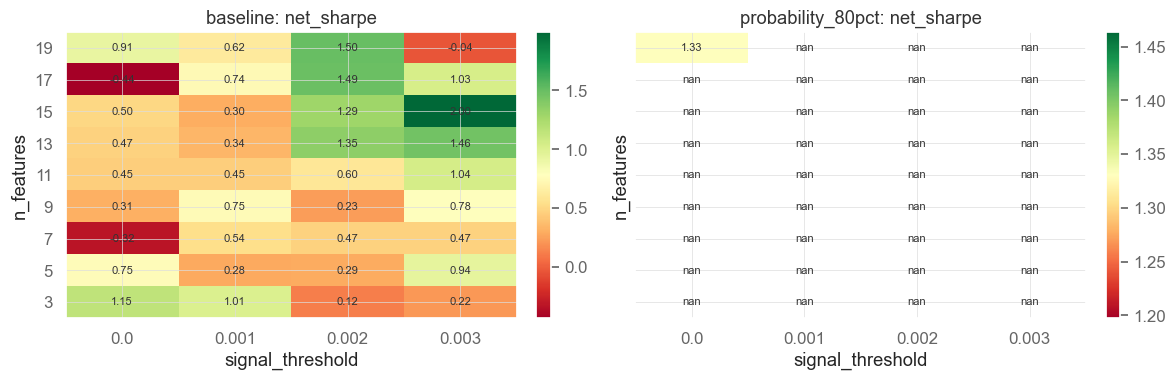

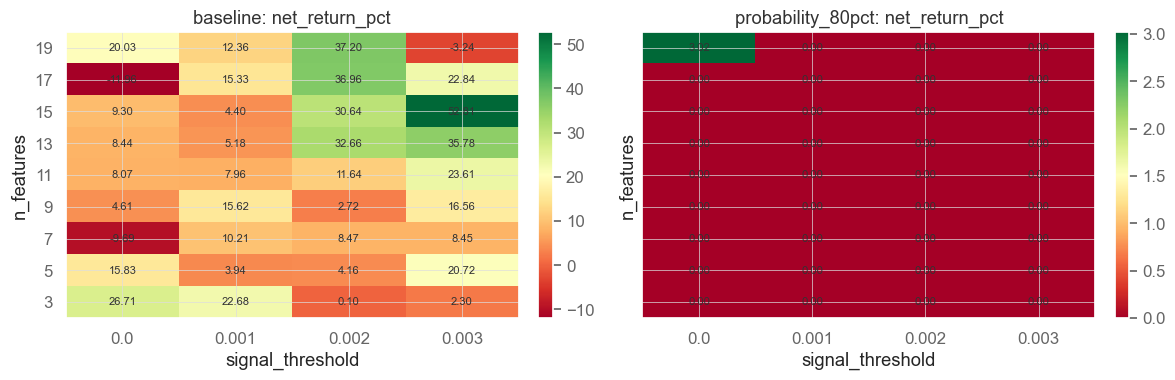

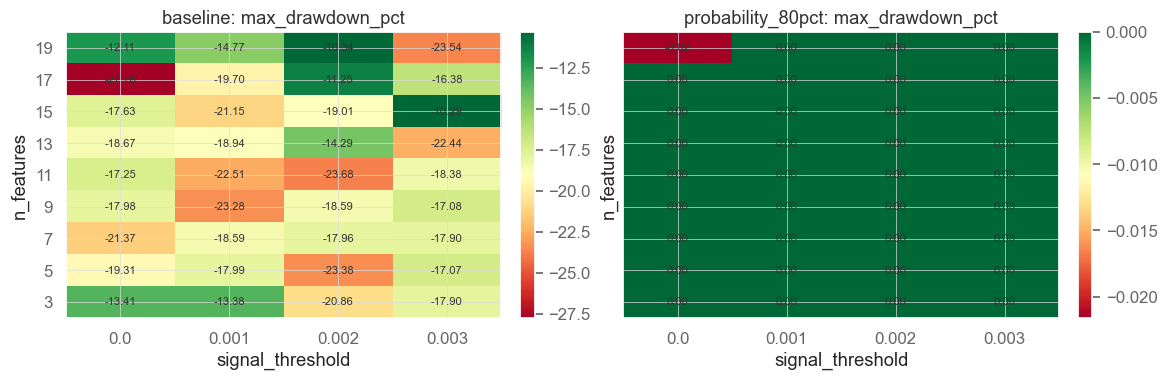

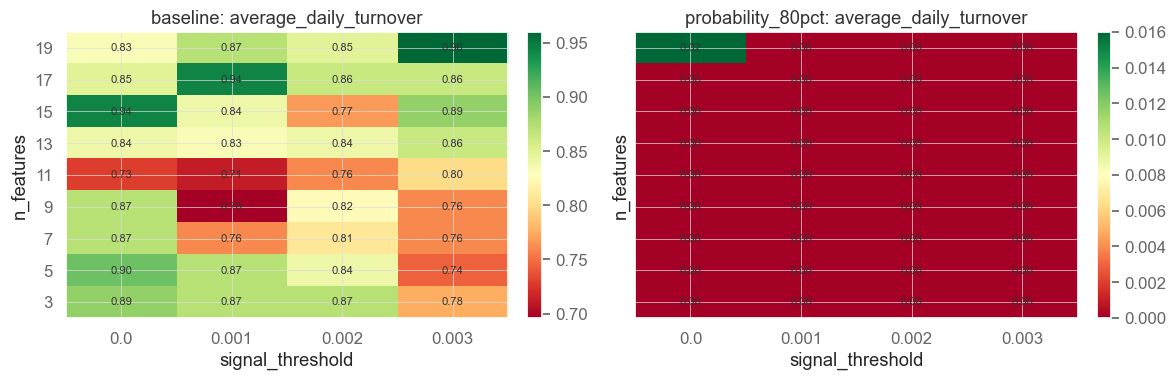

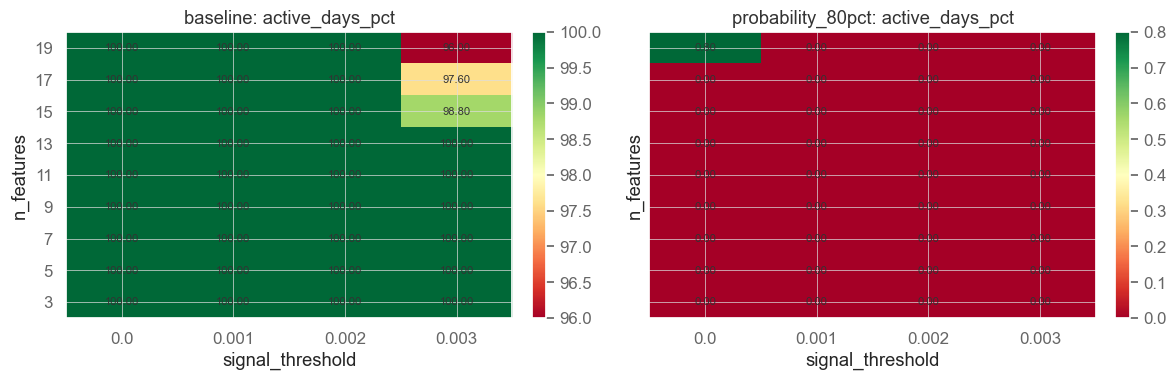

In [8]:
def plot_metric_grid(metric: str):
    fig, axes = plt.subplots(1, len(STRATEGIES), figsize=(6 * len(STRATEGIES), 4), sharey=True)
    if len(STRATEGIES) == 1:
        axes = [axes]

    for ax, strategy_name in zip(axes, STRATEGIES):
        pivot = (
            metrics_df[metrics_df["strategy"] == strategy_name]
            .pivot(index="n_features", columns="signal_threshold", values=metric)
            .sort_index(ascending=False)
        )
        image = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn")
        ax.set_title(f"{strategy_name}: {metric}")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("signal_threshold")
        ax.set_ylabel("n_features")
        for row in range(pivot.shape[0]):
            for column in range(pivot.shape[1]):
                ax.text(column, row, f"{pivot.values[row, column]:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "average_daily_turnover", "active_days_pct"]:
    plot_metric_grid(metric)

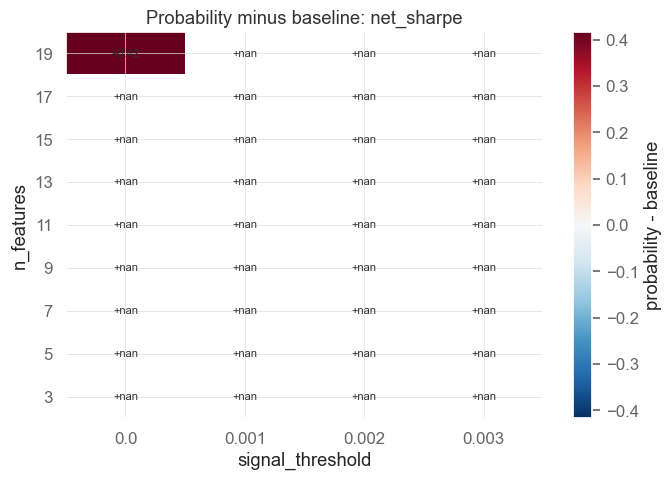

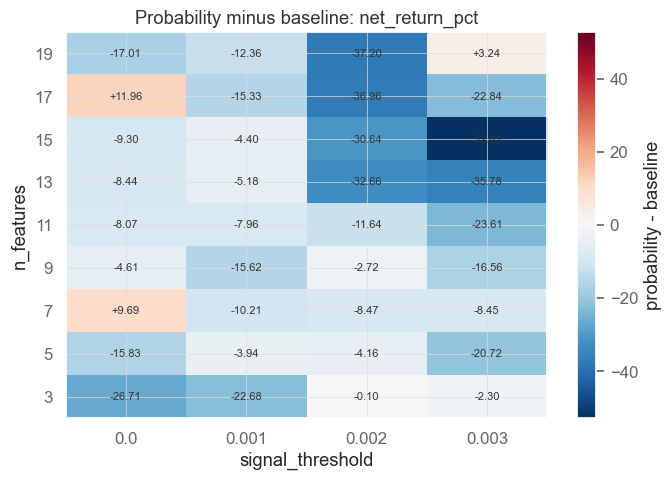

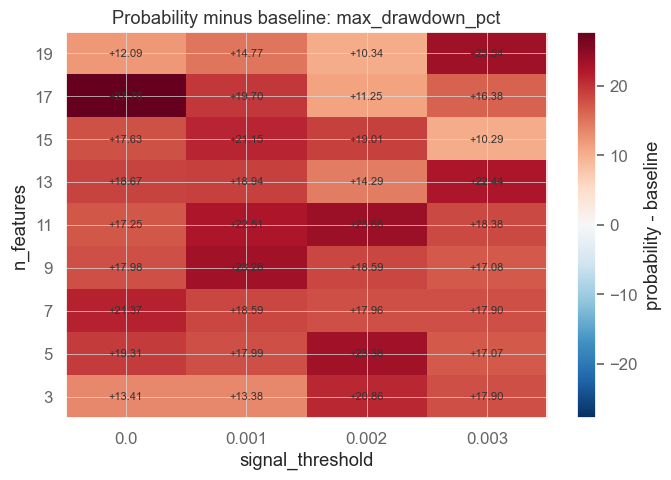

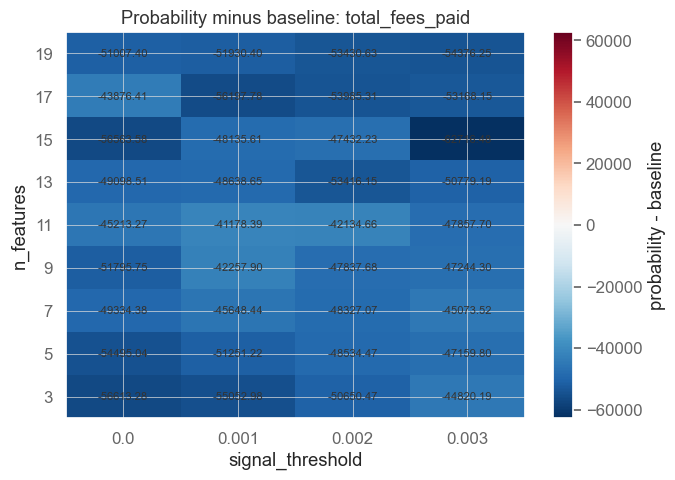

In [9]:
def plot_delta_grid(metric: str):
    pivot = (
        deltas_df[deltas_df["metric"] == metric]
        .pivot(index="n_features", columns="signal_threshold", values="probability_minus_baseline")
        .sort_index(ascending=False)
    )
    bound = np.nanmax(np.abs(pivot.values))
    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-bound, vmax=bound)
    ax.set_title(f"Probability minus baseline: {metric}")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("signal_threshold")
    ax.set_ylabel("n_features")
    for row in range(pivot.shape[0]):
        for column in range(pivot.shape[1]):
            ax.text(column, row, f"{pivot.values[row, column]:+.2f}", ha="center", va="center", fontsize=8)
    fig.colorbar(image, ax=ax, label="probability - baseline")
    plt.tight_layout()
    plt.show()


for metric in ["net_sharpe", "net_return_pct", "max_drawdown_pct", "total_fees_paid"]:
    plot_delta_grid(metric)

## 8. Prediction and Executed-Weight Agreement

The raw predicted class should generally agree because both strategies train the same MLP. Executed weights can differ when the probability strategy rejects predictions at or below 80% confidence.

In [10]:
agreement_records = []

for n_features in N_FEATURES_GRID:
    for signal_threshold in SIGNAL_THRESHOLD_GRID:
        baseline_id = make_run_id(SYMBOL, "baseline", n_features, signal_threshold)
        probability_id = make_run_id(SYMBOL, "probability_80pct", n_features, signal_threshold)
        if baseline_id not in grid_artifacts or probability_id not in grid_artifacts:
            continue

        baseline = grid_artifacts[baseline_id]
        probability = grid_artifacts[probability_id]
        raw = pd.concat(
            [
                baseline["predictions"]["prediction"].rename("baseline"),
                probability["predictions"]["prediction"].rename("probability"),
            ],
            axis=1,
        ).dropna()
        executed = pd.concat(
            [
                baseline["weights"][SYMBOL].rename("baseline"),
                probability["weights"][SYMBOL].rename("probability"),
            ],
            axis=1,
        ).dropna()
        confidence = probability["predictions"]["max_probability"]

        agreement_records.append({
            "n_features": n_features,
            "signal_threshold": signal_threshold,
            "raw_class_agreement_pct": (raw["baseline"] == raw["probability"]).mean() * 100,
            "executed_weight_agreement_pct": (executed["baseline"] == executed["probability"]).mean() * 100,
            "directional_weight_agreement_pct": (np.sign(executed["baseline"]) == np.sign(executed["probability"])).mean() * 100,
            "probability_rejection_pct": (confidence <= PROBABILITY_THRESHOLD).mean() * 100,
            "mean_max_probability": confidence.mean(),
            "median_max_probability": confidence.median(),
        })

agreement_df = pd.DataFrame(agreement_records)
display(agreement_df.round(3))
display(agreement_df.describe().round(3))

,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
0,3,0.000,100.0,0.0,0.0,100.0,0.541,0.530
1,3,0.001,100.0,0.0,0.0,100.0,0.511,0.502
2,3,0.002,100.0,0.0,0.0,100.0,0.481,0.471
3,3,0.003,100.0,0.0,0.0,100.0,0.444,0.441
4,5,0.000,100.0,0.0,0.0,100.0,0.542,0.533
5,5,0.001,100.0,0.0,0.0,100.0,0.513,0.505
6,5,0.002,100.0,0.0,0.0,100.0,0.483,0.477
7,5,0.003,100.0,0.0,0.0,100.0,0.445,0.443
8,7,0.000,100.0,0.0,0.0,100.0,0.541,0.533
9,7,0.001,100.0,0.0,0.0,100.0,0.514,0.505


,n_features,signal_threshold,raw_class_agreement_pct,executed_weight_agreement_pct,directional_weight_agreement_pct,probability_rejection_pct,mean_max_probability,median_max_probability
count,36.000,36.000,36.0,36.000,36.000,36.000,36.000,36.000
mean,11.000,0.002,100.0,0.233,0.233,99.978,0.501,0.491
std,5.237,0.001,0.0,0.791,0.791,0.133,0.037,0.035
min,3.000,0.000,100.0,0.000,0.000,99.200,0.439,0.433
25%,7.000,0.001,100.0,0.000,0.000,100.000,0.477,0.467
50%,11.000,0.002,100.0,0.000,0.000,100.000,0.506,0.495
75%,15.000,0.002,100.0,0.000,0.000,100.000,0.537,0.520
max,19.000,0.003,100.0,4.000,4.000,100.000,0.559,0.546


## 9. Probability Confidence Diagnostics

These plots show how often the 80% cutoff activates and whether higher-confidence grid points correspond to better performance.

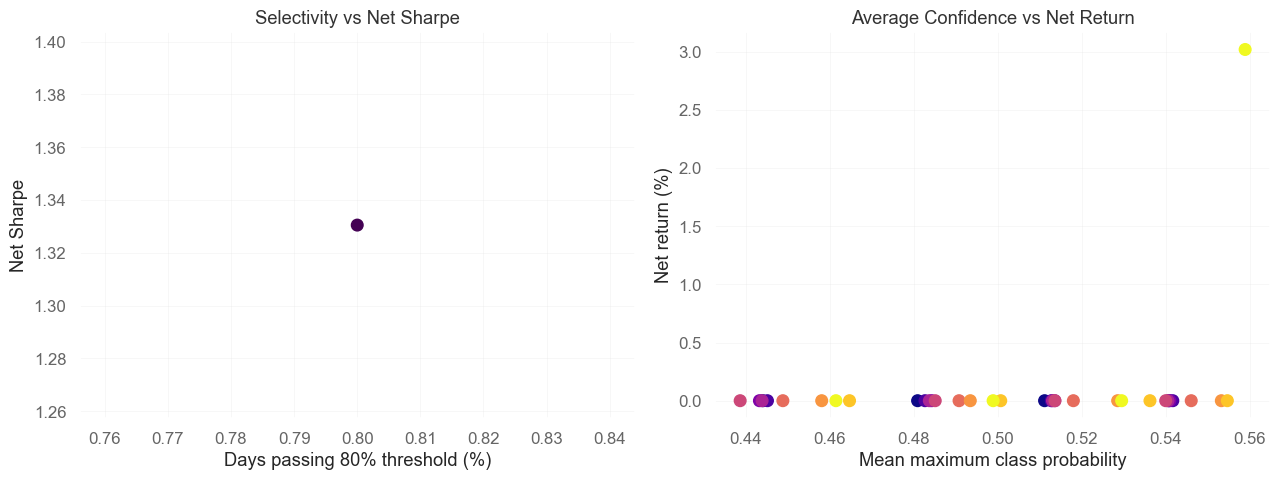

signal_threshold,0.000,0.001,0.002,0.003
n_features,,,,
19,0.8,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0
15,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0
11,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0


In [11]:
probability_metrics = metrics_df[metrics_df["strategy"] == "probability_80pct"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    probability_metrics["passes_probability_threshold_pct"],
    probability_metrics["net_sharpe"],
    c=probability_metrics["signal_threshold"],
    cmap="viridis",
    s=70,
)
axes[0].set_xlabel("Days passing 80% threshold (%)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Selectivity vs Net Sharpe")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(
    probability_metrics["mean_max_probability"],
    probability_metrics["net_return_pct"],
    c=probability_metrics["n_features"],
    cmap="plasma",
    s=70,
)
axes[1].set_xlabel("Mean maximum class probability")
axes[1].set_ylabel("Net return (%)")
axes[1].set_title("Average Confidence vs Net Return")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

confidence_grid = probability_metrics.pivot(
    index="n_features",
    columns="signal_threshold",
    values="passes_probability_threshold_pct",
).sort_index(ascending=False)
display(confidence_grid.round(2))

## 10. Equity Curves for Strategy Winners

This compares the best net-Sharpe run from each strategy with the equal-weight benchmark used by the vector backtester.

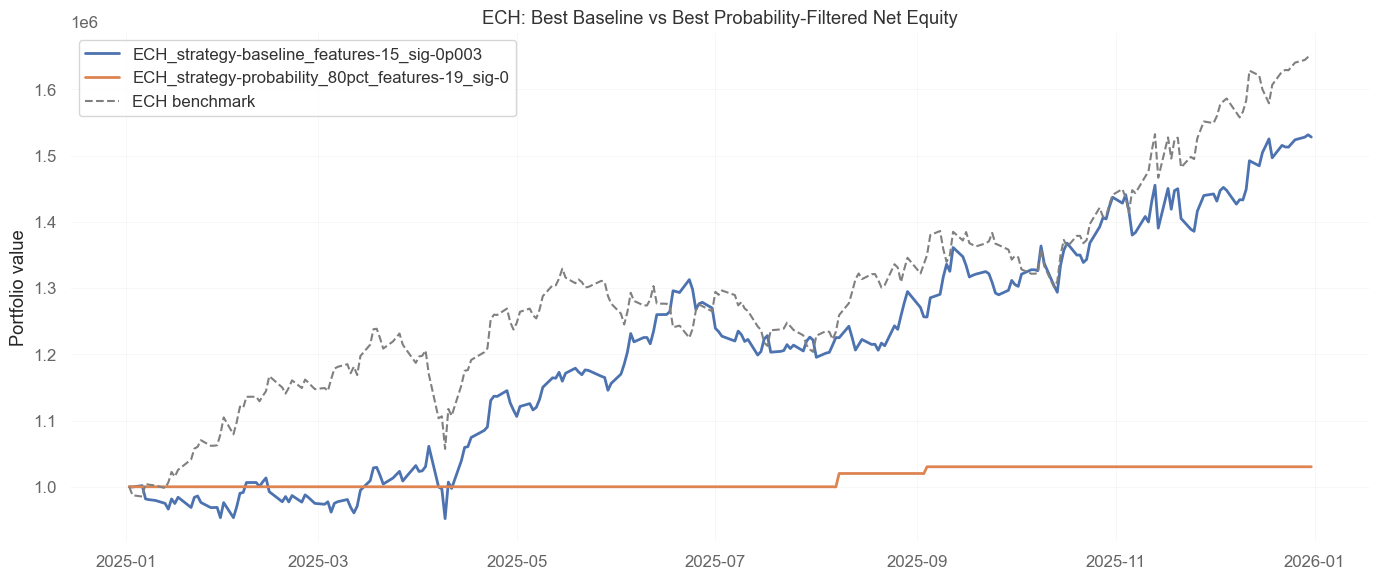

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in best_by_strategy.iterrows():
    run_id = row["run_id"]
    stats = grid_artifacts[run_id]["stats"]
    ax.plot(stats.index, stats["net_equity"], label=run_id, linewidth=2)

benchmark_stats = grid_artifacts[best_by_strategy.iloc[0]["run_id"]]["stats"]
ax.plot(
    benchmark_stats.index,
    INITIAL_CAPITAL * benchmark_stats["cum_benchmark"],
    color="gray",
    linestyle="--",
    label=f"{SYMBOL} benchmark",
)

ax.set_title(f"{SYMBOL}: Best Baseline vs Best Probability-Filtered Net Equity")
ax.set_ylabel("Portfolio value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretation Checklist

After the grid completes, compare:

- Net Sharpe and net return, not only gross return.
- Matched-grid deltas rather than only each strategy's single best case.
- Max drawdown, turnover, fees, exposure, and percentage of active days.
- Whether improvements persist across neighboring `n_features` and `signal_threshold` values.
- Raw prediction agreement versus executed-weight agreement.
- How often the probability strategy rejects predictions and whether that selectivity improves risk-adjusted performance.
- Whether the best result is robust enough to justify testing other probability thresholds in a separate experiment.